# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [1]:
source('../shared/r_funcs_repro.r')

# figure S6

- kernel: r_env, R 4.1.3
- date: 2024-02-22
- desc: supplementary figure 6

## load

In [2]:
library(tidyverse)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)

source('../shared/r_funcs_repro.r')

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.1.0
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
# basical informatino
outdir <- '../../output/figs6'
create_dir(outdir)
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'

In [4]:
gp <- 'response'

gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_lvls$response <- c('R', 'NR')
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

## s6a: chemokine receptor expression in T cells

- desc: use CD8 T cells (cyto/exhau), psuodubulk expression (min 50)

In [5]:
fpbulk <- '../../data/stage4/miscellaneous/exprs_box/chemokine_receptor_in_t_state-pbulk_count-min50.tsv'
genes <- c('ACKR3', 'CCR2', 'CCR4', 'CCR5', 'CCR6', 'CXCR1', 'CXCR2', 'CXCR3')
used_ctypes <- c('cytotoxic CD8', 'exhausted CD8')

In [6]:
exprs_pbulk <- read_tsv(fpbulk, show_col_types = F) %>% 
    column_to_rownames('symbol') %>%
    mutate(across(everything(), ~ log1p(1e6 * .x / sum(.x)))) %>%
    slice(which(rownames(.) %in% genes)) %>% 
    t() %>% 
    as.data.frame() %>% 
    rownames_to_column('sample_cellgp') %>% 
    extract(col = 'sample_cellgp', into = c('patient', 'sample_type', 'cellgp'), regex = '(.+)-(.+)_(.+)') %>%
    pivot_longer(cols = all_of(genes), names_to = 'gene', values_to = 'logcpm') %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>% 
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
exprs_pbulk %>% write_tsv(str_glue('{outdir}/figs6a-pbulk_exprs_in_t_state-chemokine_receptors.tsv'))

2026-07-18 18:10:50.132734 INFO::these clinial info will be added: response


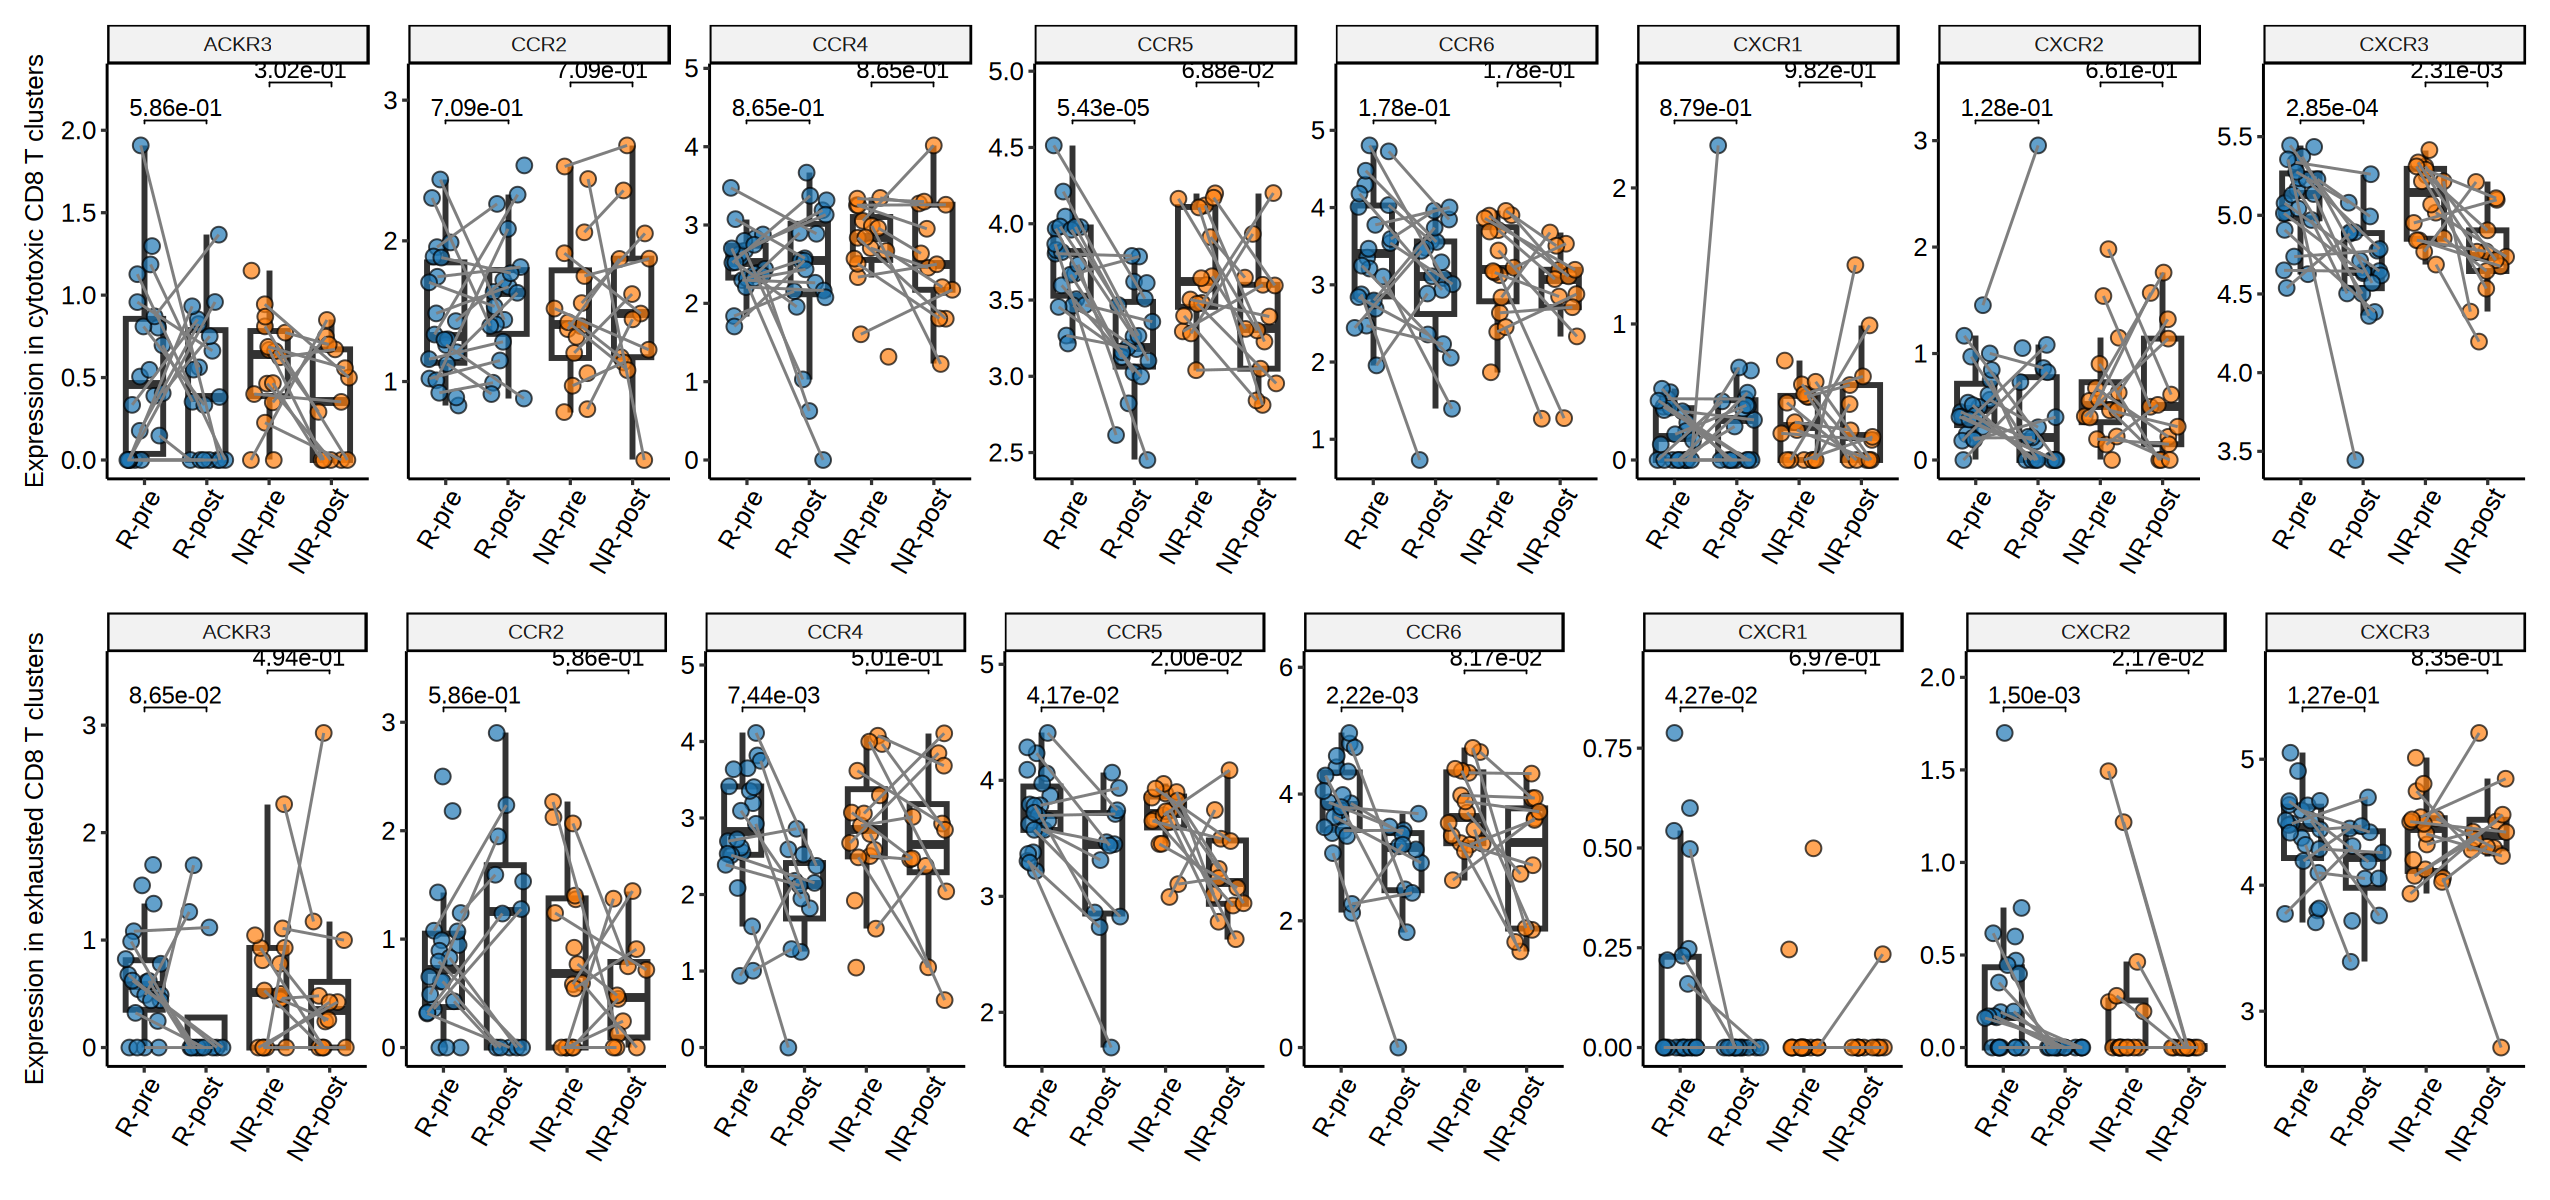

In [7]:
p_ls <- lapply(X = used_ctypes, FUN = function(nm) {
    p_sub <- exprs_pbulk %>%
        filter(cellgp == nm) %>%
        filter(!is.na(.data[[gp]])) %>%
        cell_comp_boxplot(x = c(gp, 'sample_type'), xorder = comb_order, y = 'logcpm',
                          pt_fill = gp, fill_order = gp_lvls[[gp]], facet_by = 'gene',
                          wrap_free = 'free', ncol = 10, xangle = 60) +
        labs(fill = 'Response', y = str_glue('Expression in {nm} T clusters')) +
        theme(legend.position = 'none', axis.title.x = element_blank())
    add_bh_wilcox(
        plot = p_sub,
        comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
        x = 'plot_x', y = 'logcpm', facet_by = 'gene',
        stats_file = str_glue('{outdir}/figs6a-{str_replace_all(nm, " ", "_")}-wilcoxon_bh.tsv')
    )
})
p <- wrap_plots(p_ls, ncol = 1)
ggsave(filename = str_glue('{outdir}/figs6a-box_pbulk_exprs-chemokine_receptor_in_t_state.pdf'),
       plot = p, width = 17, height = 8)
jp_opt(wd = 17, hg = 8)
print(p)


## s6b: chemokine expression in sample

In [8]:
f_pbulk <- '../../data/stage4/a06_de/cntbulk_whole_min50/bulk_by_samp.tsv'
genes <- c(
    'CCL2', 'CCL4', 'CCL5', 'CXCL6', 'CCL17', 'CCL20', 'CCL22', 
    'CXCL2', 'CXCL5', 'CXCL9', 'CXCL10', 'CXCL11', 'CXCL12'
)

In [9]:
exprs_pbulk <- read_tsv(f_pbulk, show_col_types = F) %>%
    mutate(across(where(is.numeric), ~ log1p(1e6 * .x / sum(.x)))) %>%
    filter(symbol %in% genes) %>% 
    pivot_longer(cols = -c('symbol'), names_to = 'sample', values_to = 'logcpm') %>%
    extract(col = 'sample', into = c('patient', 'sample_type'), regex = '(.+)-(.+)', remove = F) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
exprs_pbulk %>% write_tsv(str_glue('{outdir}/figs6b-pbulk_exprs_in_whole-chemokine_ligands.tsv'))

2026-07-18 18:10:56.782554 INFO::these clinial info will be added: response


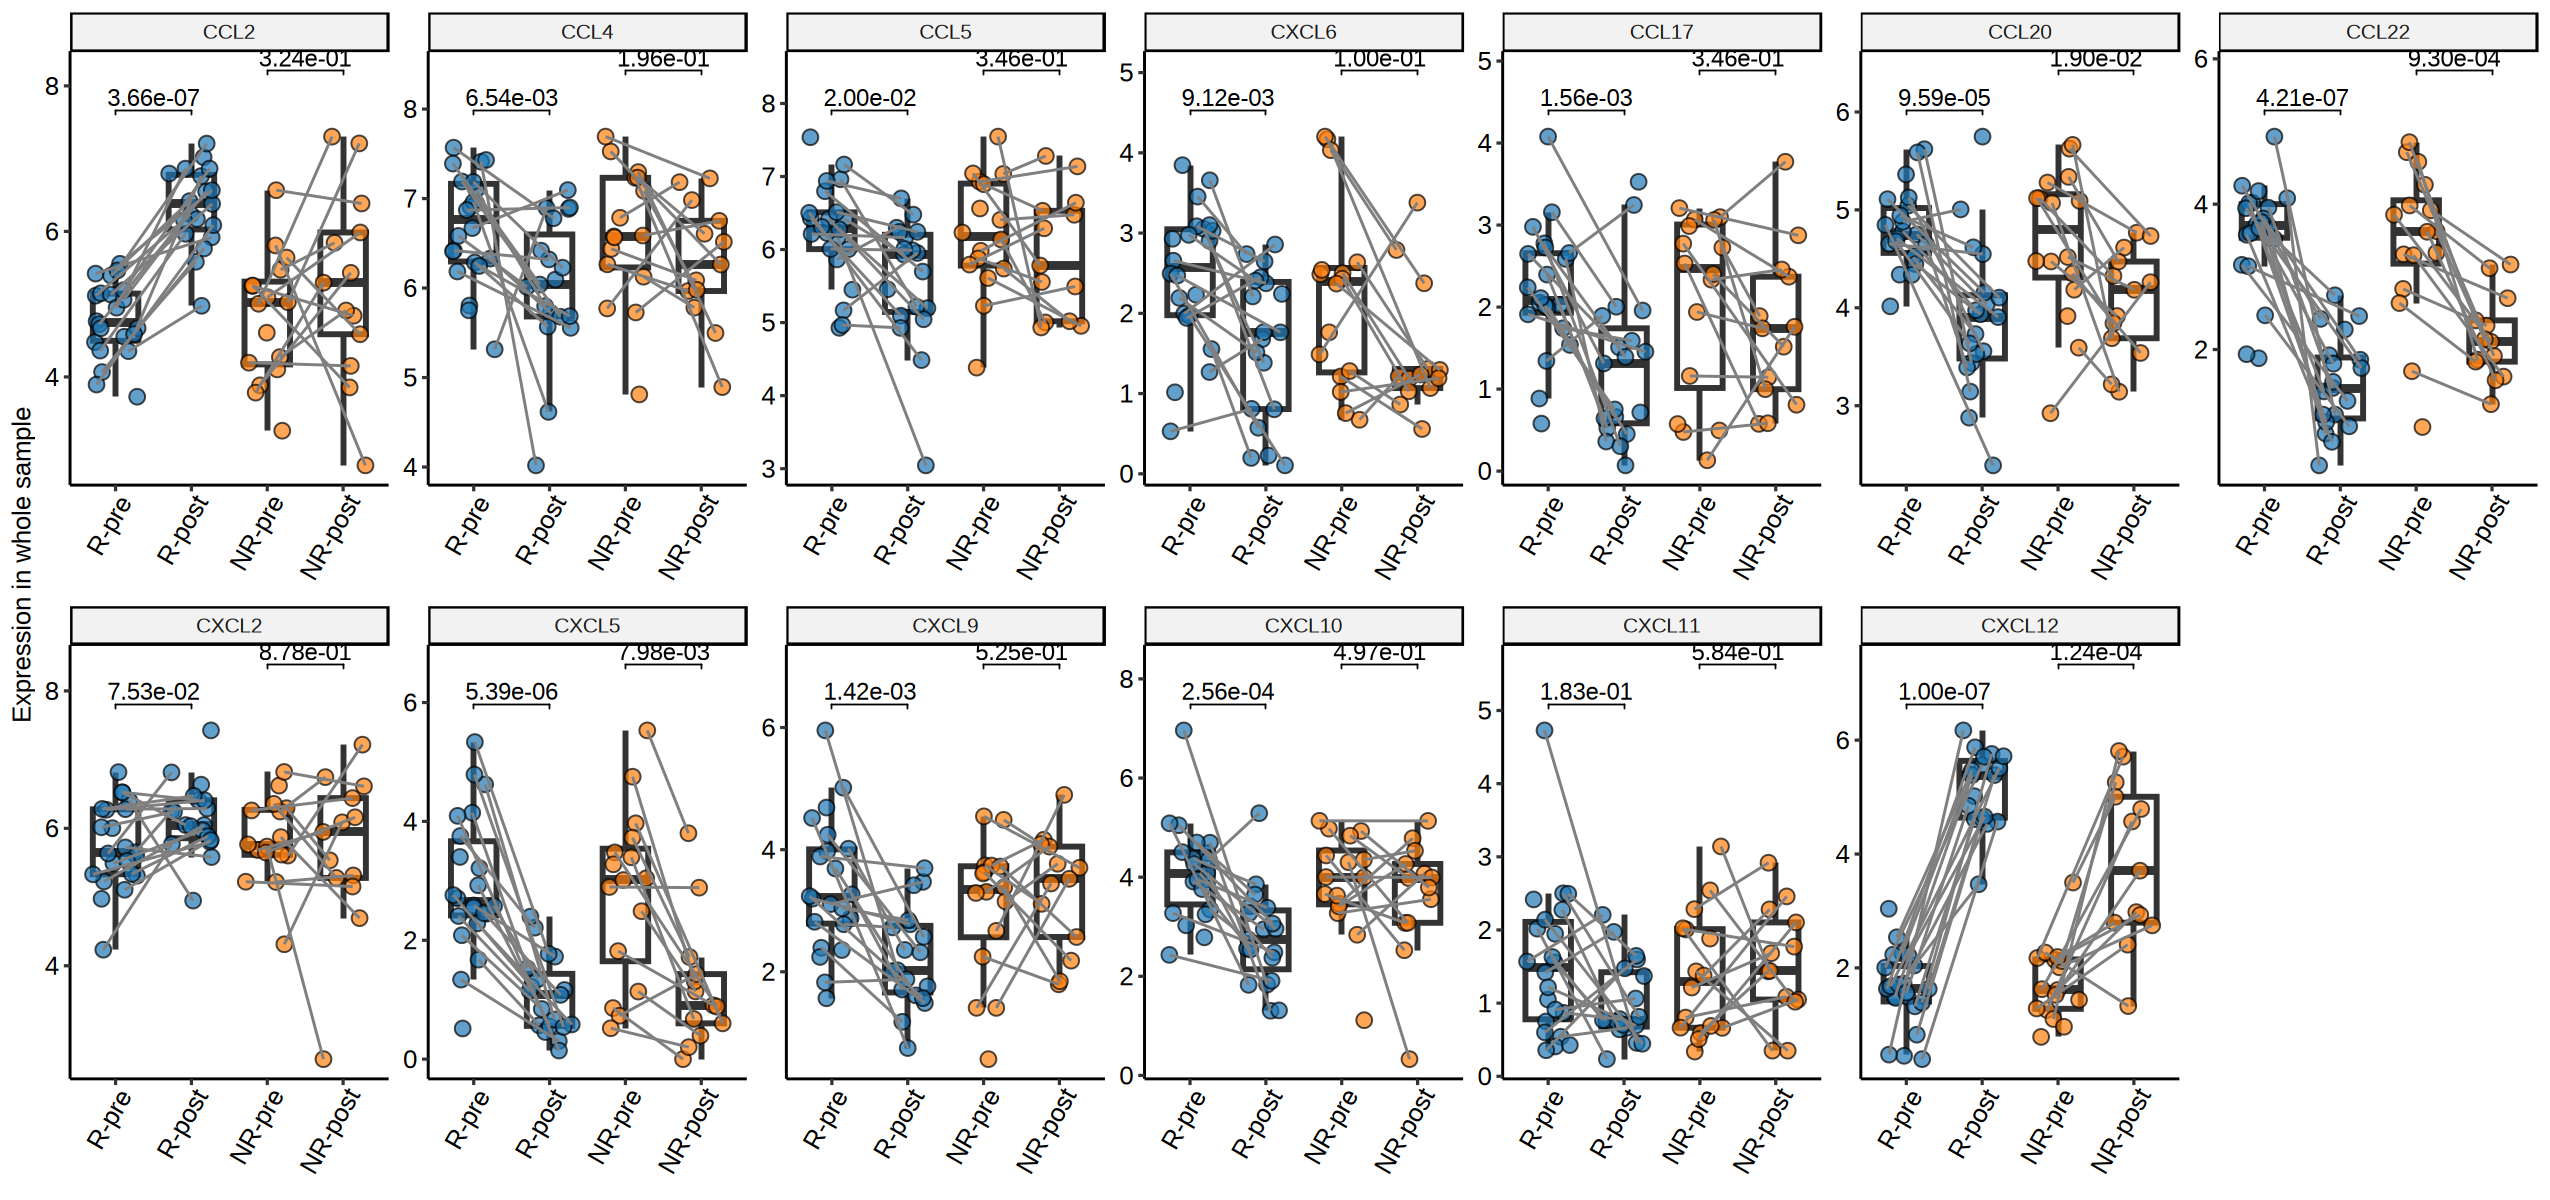

In [10]:
p <- read_tsv(str_glue('{outdir}/figs6b-pbulk_exprs_in_whole-chemokine_ligands.tsv'), show_col_types = F) %>%
    mutate(symbol = factor(symbol, genes)) %>%
    filter(!is.na(.data[[gp]])) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), xorder = comb_order, y = 'logcpm', 
                      pt_fill = gp, fill_order = gp_lvls[[gp]],
                      facet_by = 'symbol', wrap_free = 'free', ncol = 7, xangle = 60) +
    labs(fill = 'Response', y = str_glue('Expression in whole sample')) +
    theme(legend.position = 'none', axis.title.x = element_blank())
p <- add_bh_wilcox(
    plot = p,
    comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    x = 'plot_x', y = 'logcpm', facet_by = 'symbol',
    stats_file = str_glue('{outdir}/figs6b-box_chemokine_ligands-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs6b-box_pbulk_exprs-chemokine_ligand_in_whole.pdf'),
       plot = p, width = 17, height = 8)
jp_opt(wd = 17, hg = 8)
print(p)


## s6c: CXCL12 expression in major cell type

In [11]:
indir <- '../../data/stage4/a06_de/cntbulk_major_min50/'
my_gene <- 'CXCL12'

major_cell_map <- list(
    'b_plasma' = 'B & Plasma', 'myeloid' = 'Myeloid', 't' = 'T cells', 
    'endo' = 'Endothelial', 'epi' = 'Epithelial', 'fibro' = 'Fibroblast'
)

In [12]:
# obtain expression
exprs_pbulk <- rbind.data.frame()
for (nm in names(major_cell_map)) {
    exprs_pbulk <- read_tsv(str_glue('{indir}/{nm}/bulk_by_samp.tsv'), show_col_types = F) %>%
        mutate(across(where(is.numeric), ~ log1p(1e6 * .x / sum(.x)))) %>%
        filter(symbol == my_gene) %>% 
        pivot_longer(cols = -c('symbol'), names_to = 'sample', values_to = 'logcpm') %>%
        mutate(celltype = major_cell_map[[nm]]) %>%
        rbind.data.frame(exprs_pbulk)
}
exprs_pbulk <- exprs_pbulk %>%
    extract(col = 'sample', into = c('patient', 'sample_type'), regex = '(.+)-(.+)', remove = F) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

exprs_pbulk %>% write_tsv(str_glue('{outdir}/figs6c-pbulk_exprs_in_major-{my_gene}.tsv'))

2026-07-18 18:11:03.833758 INFO::these clinial info will be added: response


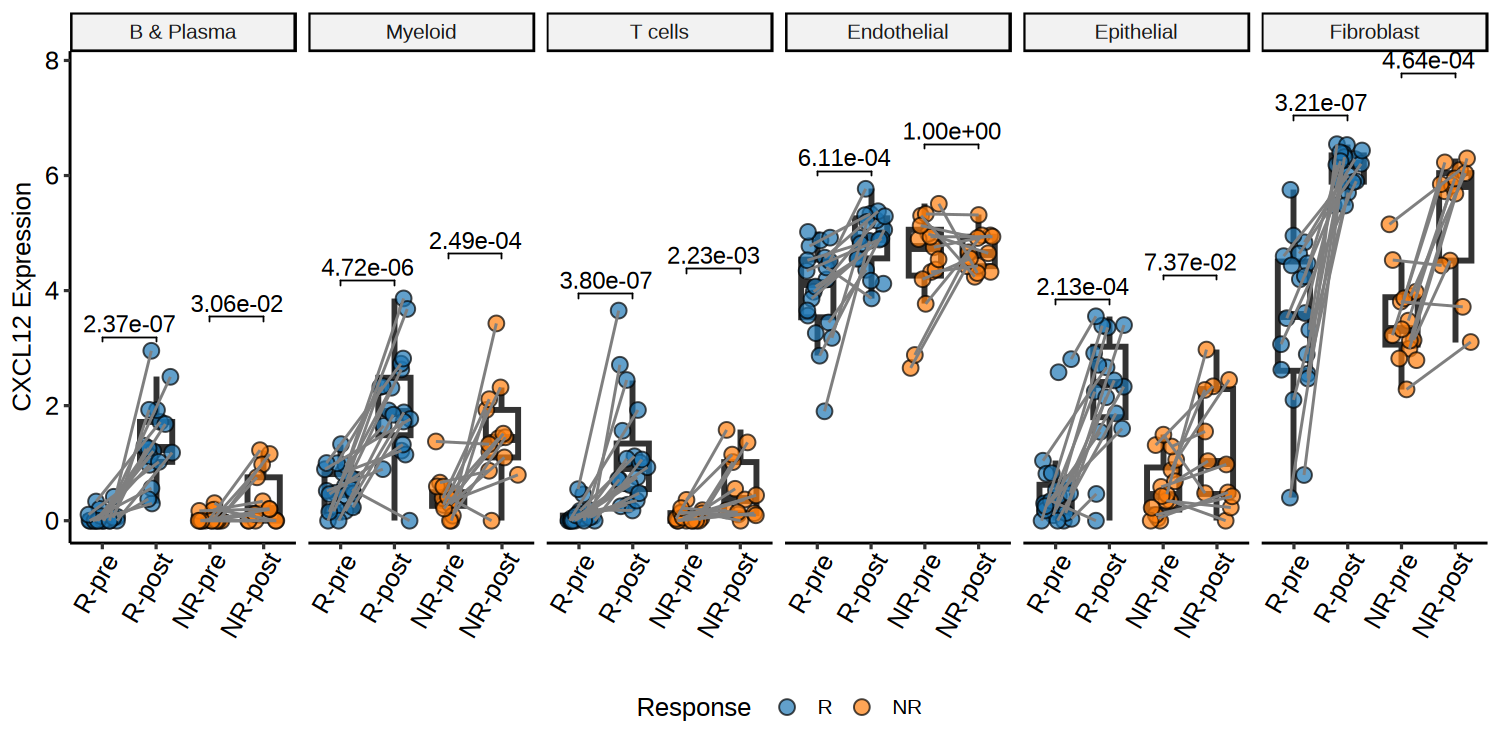

In [13]:
p <- read_tsv(str_glue('{outdir}/figs6c-pbulk_exprs_in_major-{my_gene}.tsv'), show_col_types = F) %>%
    filter(!is.na(.data[[gp]])) %>%
    mutate(celltype = factor(celltype, levels = unlist(major_cell_map))) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), xorder = comb_order, y = 'logcpm', 
                      pt_fill = gp, fill_order = gp_lvls[[gp]],
                      facet_by = 'celltype', wrap_free = 'free_x', ncol = 8, xangle = 60) +
    labs(fill = 'Response', y = str_glue('{my_gene} Expression')) +
    theme(legend.position = 'bottom', axis.title.x = element_blank())
p <- add_bh_wilcox(
    plot = p,
    comparisons = list(c('R-pre', 'R-post'), c('NR-pre', 'NR-post')),
    x = 'plot_x', y = 'logcpm', facet_by = 'celltype',
    stats_file = str_glue('{outdir}/figs6c-box_CXCL12-major_cells-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs6c-box_pbulk_exprs-{my_gene}_in_major.pdf'), width = 10, height = 5, plot = p)
jp_opt(wd = 10, hg = 5)
print(p)
